In [2]:
import os
import csv
import ast
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import matplotlib as mpl

import sys
sys.path.insert(0, str(Path("..").resolve()))
from utils import savefig

plt.rcParams['font.size'] = 14

In [3]:
noise_stds = [0, 0.2, 0.4, 0.8]

df_ctx = pd.read_pickle("../data/df_ctx.pkl")

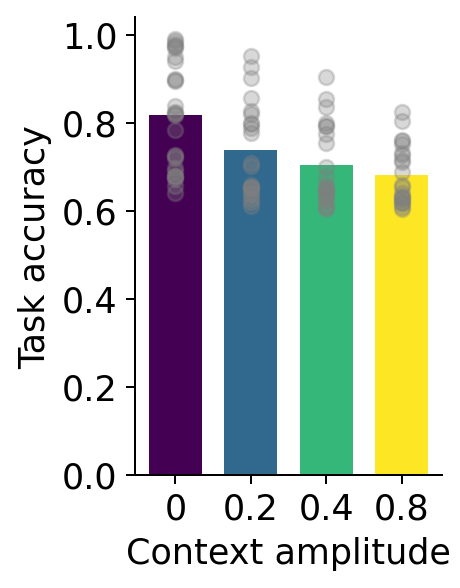

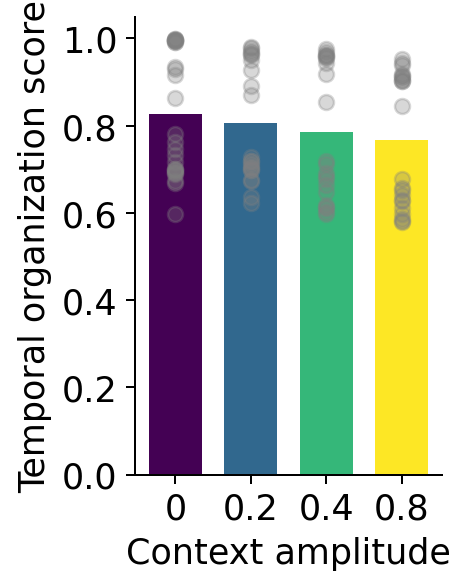

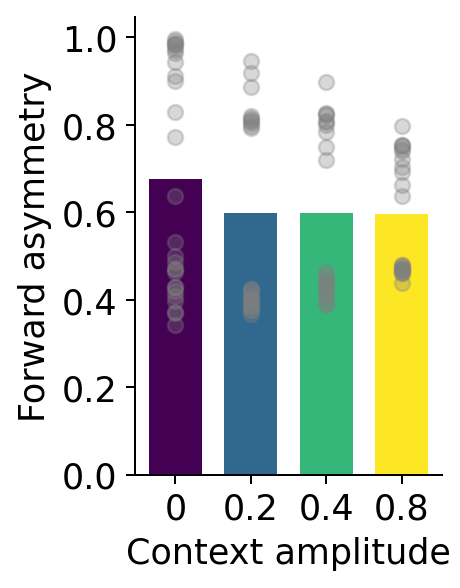

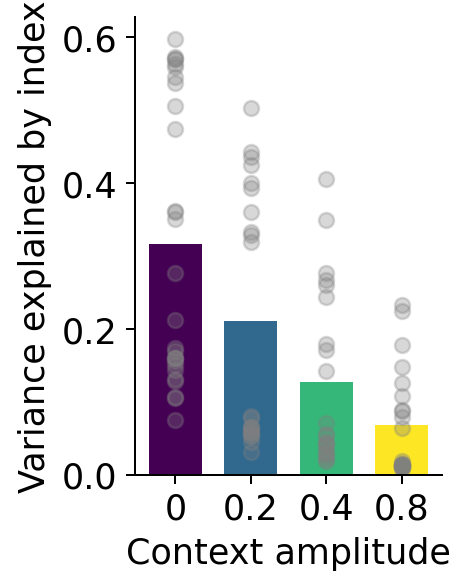

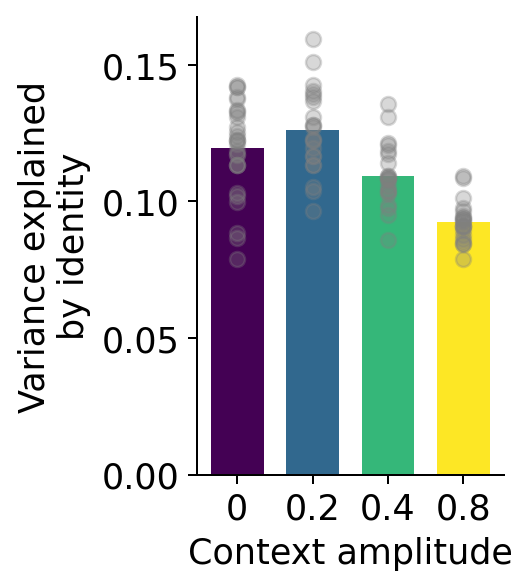

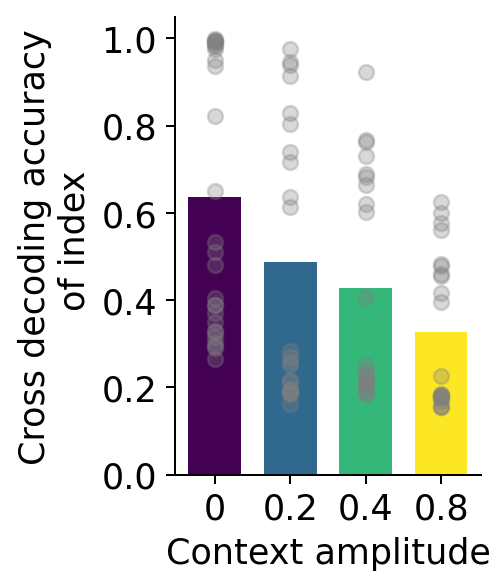

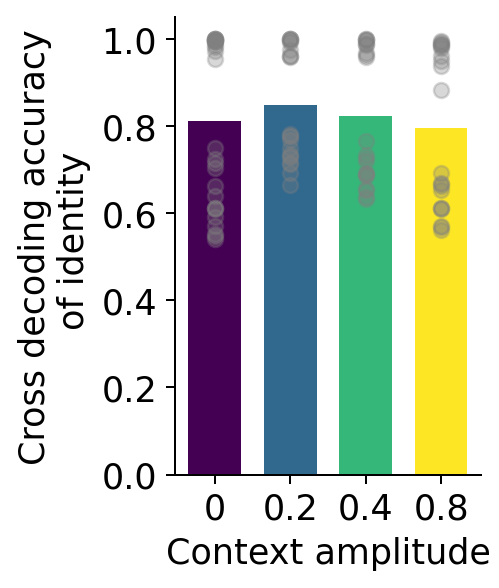

In [4]:
# bar plot of each metric for each noise std

df_ctx = df_ctx[df_ctx["accuracy"] > 0.6]


accuracy_mean_by_noise_std = df_ctx.groupby("noise_std")["accuracy"].mean()
accuracy_std_by_noise_std = df_ctx.groupby("noise_std")["accuracy"].std()

temporal_factor_mean_by_noise_std = df_ctx.groupby("noise_std")["temporal_factor"].mean()
temporal_factor_std_by_noise_std = df_ctx.groupby("noise_std")["temporal_factor"].std()

forward_asymmetry_mean_by_noise_std = df_ctx.groupby("noise_std")["forward_asymmetry"].mean()
forward_asymmetry_std_by_noise_std = df_ctx.groupby("noise_std")["forward_asymmetry"].std()

variance_explained_index_mean_by_noise_std = df_ctx.groupby("noise_std")["explained_variance_index"].mean()
variance_explained_identity_mean_by_noise_std = df_ctx.groupby("noise_std")["explained_variance_identity"].mean()

cross_decoding_accuracy_index_mean_by_noise_std = df_ctx.groupby("noise_std")["cross_decoding_accuracy_index"].mean()
cross_decoding_accuracy_identity_mean_by_noise_std = df_ctx.groupby("noise_std")["cross_decoding_accuracy_identity"].mean()


viridis = plt.get_cmap('viridis', lut=len(noise_stds))
colors = [viridis(i) for i in range(len(noise_stds))]

noise_std_nums = np.arange(len(noise_stds))
df_ctx["noise_std_num"] = df_ctx["noise_std"].map(lambda x: noise_std_nums[noise_stds.index(x)])

def plot_mean_scatter_bar(mean, df, df_label, noise_stds, y_label):
    plt.figure(figsize=(2.2, 3.3), dpi=180)
    plt.bar(np.arange(len(noise_stds)), mean, width=0.7, color=colors)
    plt.xticks(np.arange(len(noise_stds)), noise_stds)
    plt.scatter(df["noise_std_num"], df[df_label], color="gray", alpha=0.3)
    plt.xlabel("Context amplitude")
    plt.ylabel(y_label)
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.show()

plot_mean_scatter_bar(accuracy_mean_by_noise_std, df_ctx, "accuracy", noise_stds, "Task accuracy")
plot_mean_scatter_bar(temporal_factor_mean_by_noise_std, df_ctx, "temporal_factor", noise_stds, "Temporal organization score")
plot_mean_scatter_bar(forward_asymmetry_mean_by_noise_std, df_ctx, "forward_asymmetry", noise_stds, "Forward asymmetry")
plot_mean_scatter_bar(variance_explained_index_mean_by_noise_std, df_ctx, "explained_variance_index", noise_stds, "Variance explained by index")
plot_mean_scatter_bar(variance_explained_identity_mean_by_noise_std, df_ctx, "explained_variance_identity", noise_stds, "Variance explained\nby identity")
plot_mean_scatter_bar(cross_decoding_accuracy_index_mean_by_noise_std, df_ctx, "cross_decoding_accuracy_index", noise_stds, "Cross decoding accuracy\n of index")
plot_mean_scatter_bar(cross_decoding_accuracy_identity_mean_by_noise_std, df_ctx, "cross_decoding_accuracy_identity", noise_stds, "Cross decoding accuracy\n of identity")


In [5]:
def plot_crp_by_group(data, group_values, group_title, colors):
    plt.figure(figsize=(3.5, 3), dpi=180)

    print(data.shape[1])

    mid_point = data.shape[1] // 2 + 1

    print(mid_point)

    for i in range(len(group_values)):
        plt.plot(np.arange(-mid_point+2, 0), data[i, 1:mid_point-1], label=group_values[i], color=colors[i])
        plt.plot(np.arange(1, mid_point-1), data[i, mid_point:-1], color=colors[i])
    
    plt.xlabel("Lag")
    plt.ylabel("Conditional\nrecall probability")
    plt.legend(
        title=group_title, 
        bbox_to_anchor=(1.0, 1.0), 
        loc="upper left", 
        borderaxespad=0, 
        frameon=False
    )
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.show()

15
8


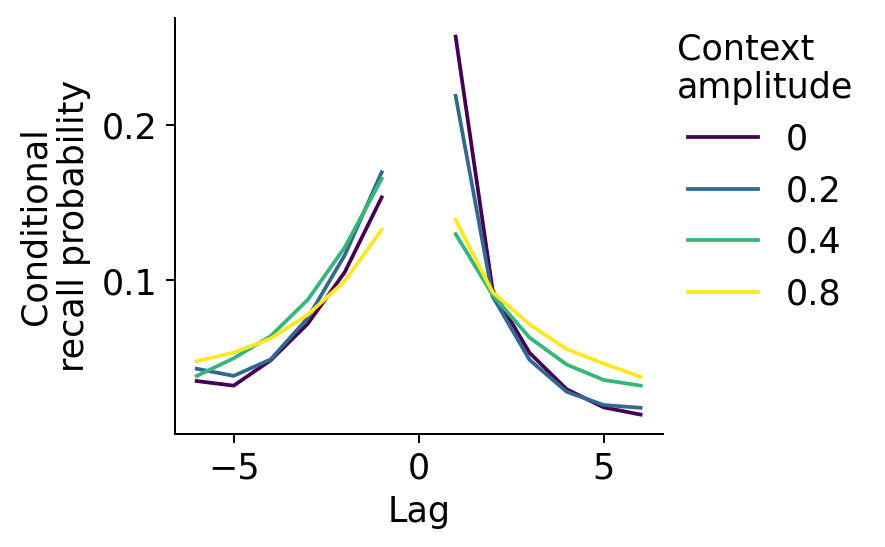

In [9]:
crp_by_noise_std = df_ctx[df_ctx["flush_noise"] == 0.9].groupby("noise_std")["crp_curve"]
# print(crp_by_noise_std.head())
mean_crp_by_noise_std = []
for name, group in crp_by_noise_std:
    crp_arrays = np.array(group.tolist())
    mean_crp = np.mean(np.stack(crp_arrays, axis=0), axis=0)
    mean_crp_by_noise_std.append(mean_crp)
mean_crp_by_noise_std = np.array(mean_crp_by_noise_std)

viridis = plt.get_cmap('viridis', lut=len(noise_stds))
colors = [viridis(i) for i in range(len(noise_stds))]

plot_crp_by_group(mean_crp_by_noise_std, noise_stds, "Context\namplitude", colors)



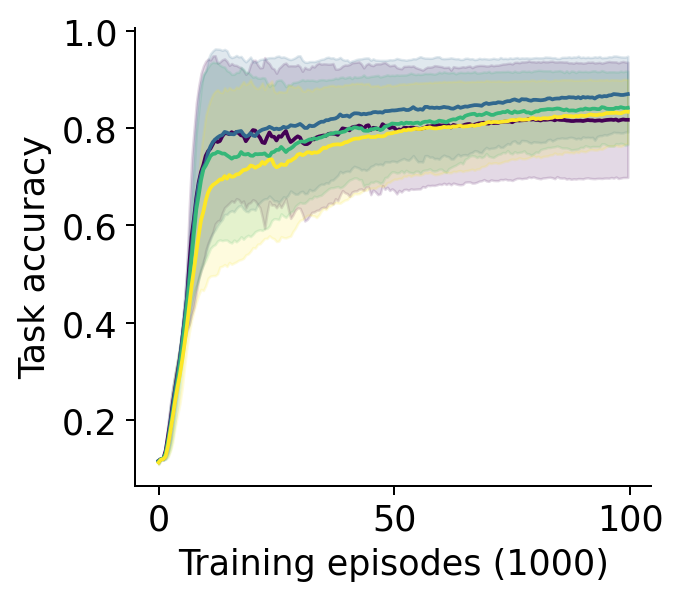

In [ ]:
# training_accuracy_by_tdf = df_tdf[(df_tdf["pretrained"] == True) & (df_tdf["eta"] == 0.01)].groupby("temporal_discount_factor")["training_accuracy"].mean()
training_accuracy_by_noise_std = df_ctx.groupby("noise_std")["training_accuracy"].mean()

plt.figure(figsize=(3.7, 3.3), dpi=180)
colors = plt.cm.viridis(np.linspace(0, 1, len(training_accuracy_by_noise_std)))
for i, (noise_std, acc) in enumerate(training_accuracy_by_noise_std.items()):
    plt.plot(acc[:200], label=f"noise std = {noise_std:.1f}", color=colors[i])
    std_dev = np.std(np.stack(df_ctx[df_ctx["noise_std"] == noise_std]["training_accuracy"]), axis=0)
    plt.fill_between(range(len(acc[:200])), acc[:200] - std_dev, acc[:200] + std_dev, color=colors[i], alpha=0.15)
    
# set the legend to the right of the plot
ax = plt.gca()
# ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False)
plt.xticks(np.arange(0, 201, 100), np.arange(0, 101, 50))
plt.xlabel("Training episodes (1000)")
plt.ylabel("Task accuracy")
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.show()


In [ ]:
df_samediff_raw = pd.read_pickle("../data/df_samediff.pkl")

In [ ]:
filter_model_nums = df_samediff_raw[(df_samediff_raw["noise_type"] == "same") & (df_samediff_raw["test_noise_type"] == "same") & (df_samediff_raw["accuracy"] > 0.5)]["model_num"].tolist()
print(filter_model_nums)
filter_model_nums2 = df_samediff_raw[(df_samediff_raw["noise_type"] == "diff") & (df_samediff_raw["test_noise_type"] == "diff") & (df_samediff_raw["accuracy"] > 0.5)]["model_num"].tolist()
print(filter_model_nums2)
df_samediff = df_samediff_raw[((df_samediff_raw["noise_type"] == "same") & (df_samediff_raw["model_num"].isin(filter_model_nums))) |
                         ((df_samediff_raw["noise_type"] == "diff") & (df_samediff_raw["model_num"].isin(filter_model_nums2))) |
                         ((df_samediff_raw["noise_type"] == "fixed") & (df_samediff_raw["accuracy"] > 0.5)) |
                         ((df_samediff_raw["noise_type"] == "none") & (df_samediff_raw["accuracy"] > 0.5))].copy()
print(len(df_samediff))

df_samediff["noise_type_int"] = df_samediff["noise_type"].map({"same": 2, "diff": 3, "fixed": 0, "none": 1})
df_samediff["test_noise_type_int"] = df_samediff["test_noise_type"].map({"same": 2, "diff": 3, "fixed": 0, "none": 1})


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 19]
[0, 1, 2, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19]
111


noise_type_int  test_noise_type_int
0               0                      0.921462
1               1                      0.739492
2               2                      0.802289
                3                      0.648441
3               2                      0.701103
                3                      0.698257
Name: accuracy, dtype: float64


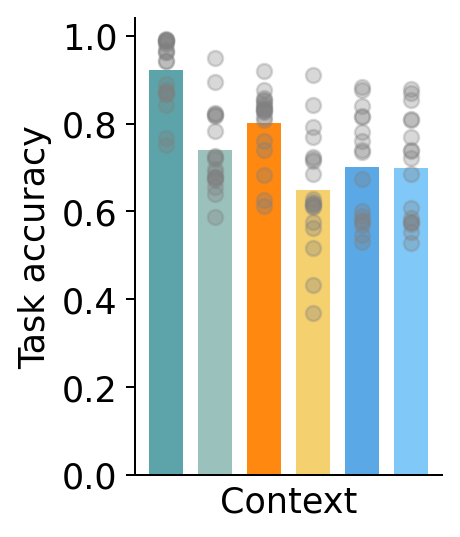

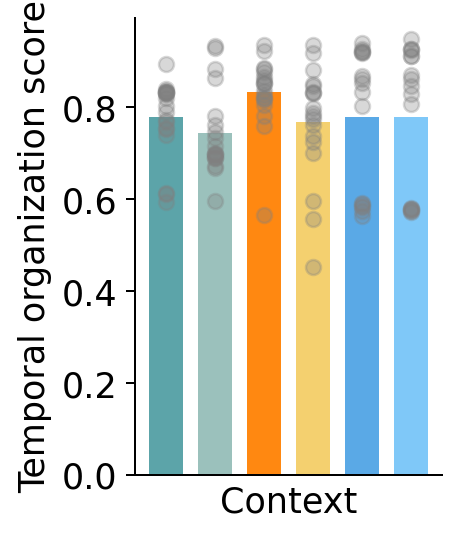

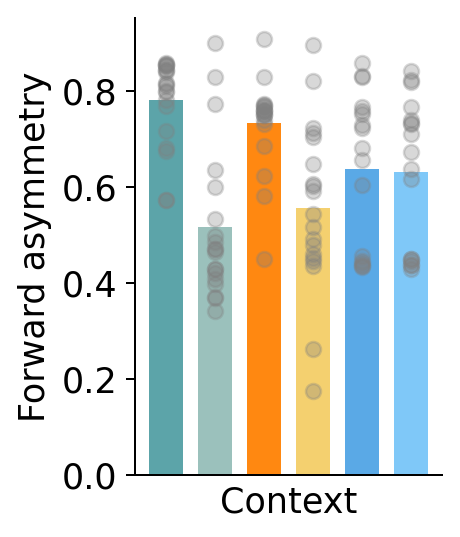

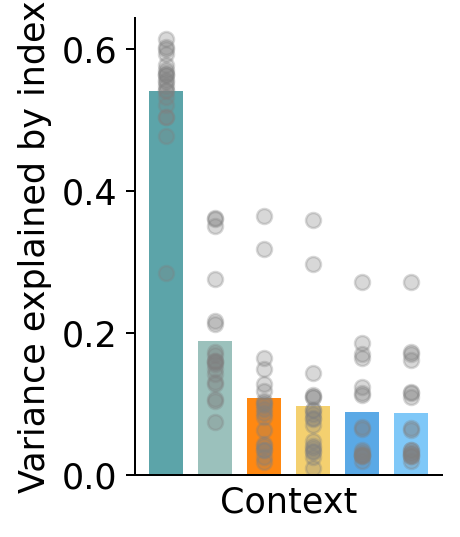

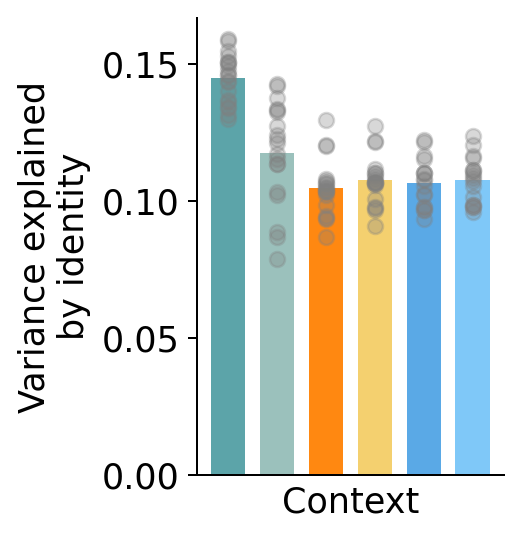

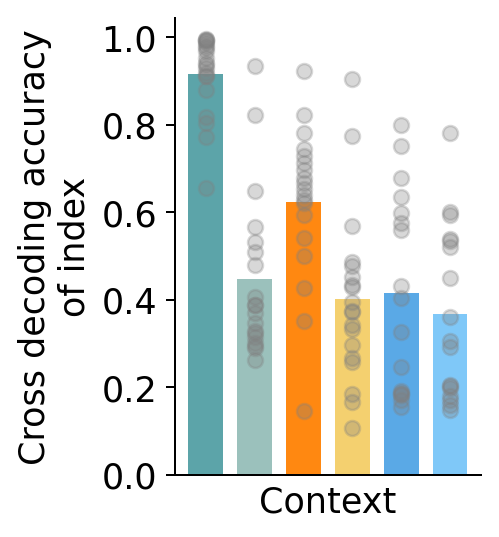

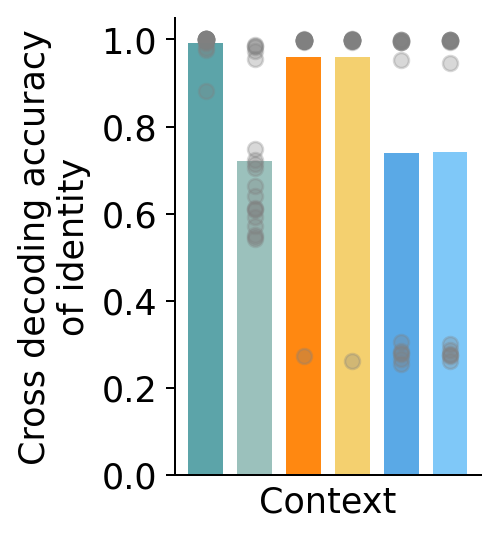

In [ ]:

accuracy_mean_by_noise_type = df_samediff.groupby(["noise_type_int", "test_noise_type_int"])["accuracy"].mean()
accuracy_std_by_noise_type = df_samediff.groupby(["noise_type_int", "test_noise_type_int"])["accuracy"].std()
print(accuracy_mean_by_noise_type)

temporal_factor_mean_by_noise_type = df_samediff.groupby(["noise_type_int", "test_noise_type_int"])["temporal_factor"].mean()
temporal_factor_std_by_noise_type = df_samediff.groupby(["noise_type_int", "test_noise_type_int"])["temporal_factor"].std()

forward_asymmetry_mean_by_noise_type = df_samediff.groupby(["noise_type_int", "test_noise_type_int"])["forward_asymmetry"].mean()
forward_asymmetry_std_by_noise_type = df_samediff.groupby(["noise_type_int", "test_noise_type_int"])["forward_asymmetry"].std()

variance_explained_index_mean_by_noise_type = df_samediff.groupby(["noise_type_int", "test_noise_type_int"])["explained_variance_index"].mean()
variance_explained_identity_mean_by_noise_type = df_samediff.groupby(["noise_type_int", "test_noise_type_int"])["explained_variance_identity"].mean()

cross_decoding_accuracy_index_mean_by_noise_type = df_samediff.groupby(["noise_type_int", "test_noise_type_int"])["cross_decoding_accuracy_index"].mean()
cross_decoding_accuracy_identity_mean_by_noise_type = df_samediff.groupby(["noise_type_int", "test_noise_type_int"])["cross_decoding_accuracy_identity"].mean()


# colors = ["black", "tab:blue", "tab:red"]
colors = ["#5CA4A9", "#9BC1BC", "#FF8811", "#F4D06F", "#5AA9E6", "#7FC8F8"]

def plot_mean_scatter_bar(mean, df, df_label, y_label):
    plt.figure(figsize=(2.2, 3.3), dpi=180)
    plt.bar(np.arange(len(mean)), mean, width=0.7, color=colors)
    plt.scatter(df["mark"], df[df_label], color="gray", alpha=0.3)
    # plt.xticks(np.arange(3), ["baseline", "same", "diff"], fontsize=12, rotation=30)
    plt.xticks([])
    plt.xlabel("Context")
    plt.ylabel(y_label)
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.show()

# print(df_samediff["noise_type"])
plot_mean_scatter_bar(accuracy_mean_by_noise_type, df_samediff, "accuracy", "Task accuracy")
plot_mean_scatter_bar(temporal_factor_mean_by_noise_type, df_samediff, "temporal_factor", "Temporal organization score")
plot_mean_scatter_bar(forward_asymmetry_mean_by_noise_type, df_samediff, "forward_asymmetry", "Forward asymmetry")
plot_mean_scatter_bar(variance_explained_index_mean_by_noise_type, df_samediff, "explained_variance_index", "Variance explained by index")
plot_mean_scatter_bar(variance_explained_identity_mean_by_noise_type, df_samediff, "explained_variance_identity", "Variance explained\nby identity")
plot_mean_scatter_bar(cross_decoding_accuracy_index_mean_by_noise_type, df_samediff, "cross_decoding_accuracy_index", "Cross decoding accuracy\nof index")
plot_mean_scatter_bar(cross_decoding_accuracy_identity_mean_by_noise_type, df_samediff, "cross_decoding_accuracy_identity", "Cross decoding accuracy\nof identity")


15
8


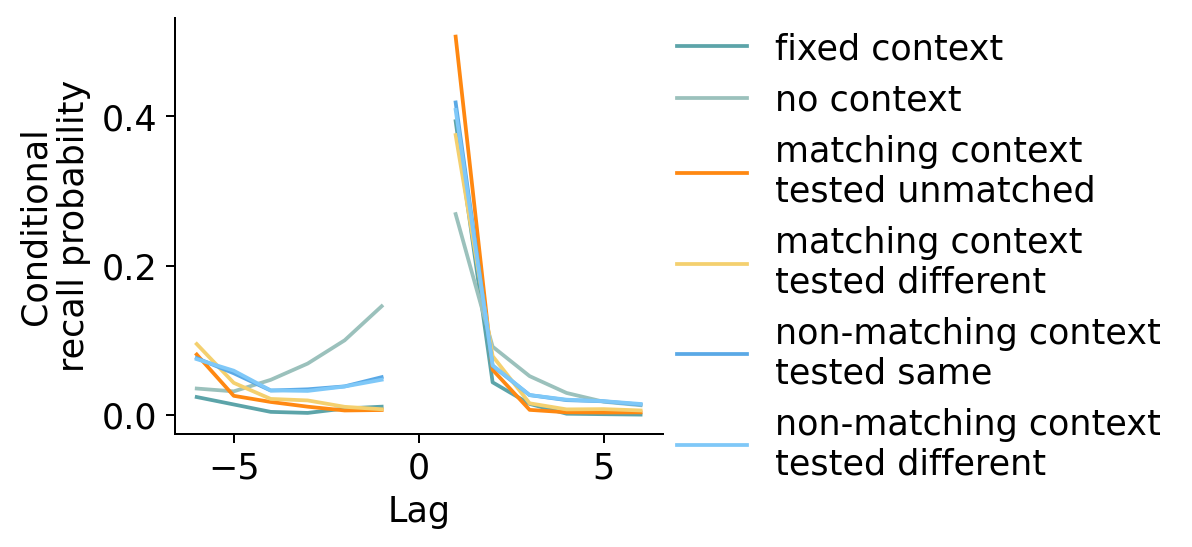

In [ ]:
crp_by_noise_std = df_samediff.groupby(["noise_type_int", "test_noise_type_int"])["crp_curve"]
# print(crp_by_noise_std.head())
mean_crp_by_noise_std = []
for name, group in crp_by_noise_std:
    crp_arrays = np.array(group.tolist())
    mean_crp = np.mean(np.stack(crp_arrays, axis=0), axis=0)
    mean_crp_by_noise_std.append(mean_crp)
mean_crp_by_noise_std = np.array(mean_crp_by_noise_std)

# colors = ["black", "tab:blue", "tab:red"]
plot_crp_by_group(mean_crp_by_noise_std, ["fixed context", "no context", "matching context\ntested unmatched", "matching context\ntested different", "non-matching context\ntested same", "non-matching context\ntested different"], "", colors)


### Semantic information

In [ ]:
data_semantic = []

data_folder = Path("./experiments/Semantic/figures/ValueMemoryGRU")
training_curve_folder = Path("./experiments/Semantic/saved_models/ValueMemoryGRU")
semantic_folder = Path("./experiments/Semantic/figures/semantic/ValueMemoryGRU")


# setup_names = ["setup_extra_hierarchy_amp02", "setup_extra_hierarchy_amp02_gamma0", 
#                 "setup_extra_hierarchy_amp05", "setup_extra_hierarchy_amp05_gamma0", 
#                 "setup_extra_hierarchy_amp02_gamma09_flush09", "setup_extra_hierarchy_amp05_gamma09_flush09",
#                 "setup_extra_sigma02"]
# semantic_type = ["hierarchical_binary", "hierarchical_binary", 
#                 "hierarchical_binary", "hierarchical_binary", 
#                 "hierarchical_binary", "hierarchical_binary", 
#                 "gaussian_identity"]
# semantic_amp = [0.2, 0.2, 0.5, 0.5, 
#                 0.2, 0.5, 
#                 0.2]
# semantic_gamma = [1.0, 0, 1.0, 0, 
#                 0.9, 0.9, 
#                 1.0]
# semantic_flush = [1.0, 1.0, 1.0, 1.0, 
#                 0.9, 0.9, 
#                 1.0]
# marks = np.arange(len(setup_names)) + 1

setup_name = "setup_extra_hierarchy_amp"
# # semantic_amp = [0.2, 0.3, 0.4, 0.5]
semantic_amp = [0, 0.3, 0.5]
# setup_name = "setup_extra_rumelhart_amp"
# semantic_amp = [0.5, 1]
setup_names = [setup_name + str(amp).replace(".", "") for amp in semantic_amp]
print(setup_names)
# setup_names = []
# for noise_std in noise_stds:
#     setup_names.append(setup_base_name + str(noise_std).replace(".", ""))



seq_len = 8

exp = "semantic"

for i, setup_name in enumerate(setup_names):
    parameters = {
        # "semantic_type": semantic_type[i],
        "semantic_amp": semantic_amp[i],
        # "semantic_gamma": semantic_gamma[i],
        # "seq_len": seq_len,
        # "mark": marks[i],
    }
    
    training_data_length = 200
    for i in range(20):
        data_path = data_folder / setup_name / str(i)
        training_data_path = training_curve_folder / (setup_name + "-" + str(i))
        if os.path.exists(data_path/"contiguity_effect.csv") and os.path.exists(data_path/"cross_acc.npy"):
            data_single_model = load_data(data_path, training_data_path, i, exp, parameters, training_data_length)
            if data_single_model:
                data_single_model["pretrained"] = False
                semantic_contiguity_data = np.load(semantic_folder / setup_name / str(i) / "data" / "semantic_contiguity_results.npy")
                data_single_model["semantic_contiguity"] = semantic_contiguity_data
                semantic_contiguity_baseline_data = np.load(semantic_folder / setup_name / str(i) / "data" / "semantic_contiguity_baseline.npy")
                data_single_model["semantic_contiguity_baseline"] = semantic_contiguity_baseline_data
                data_semantic.append(data_single_model)

df_semantic = pd.DataFrame(data_semantic)
df_semantic = df_semantic[df_semantic["accuracy"] > 0.7]
print(len(df_semantic))


['setup_extra_hierarchy_amp0', 'setup_extra_hierarchy_amp03', 'setup_extra_hierarchy_amp05']


KeyError: 'accuracy'

In [ ]:
df_semantic.to_pickle("./data/df_semantic.pkl")

In [ ]:
semantic_amp = [0.0, 0.3, 0.5]

df_semantic = pd.read_pickle("../data/df_semantic.pkl")

(3, 15)
15
8


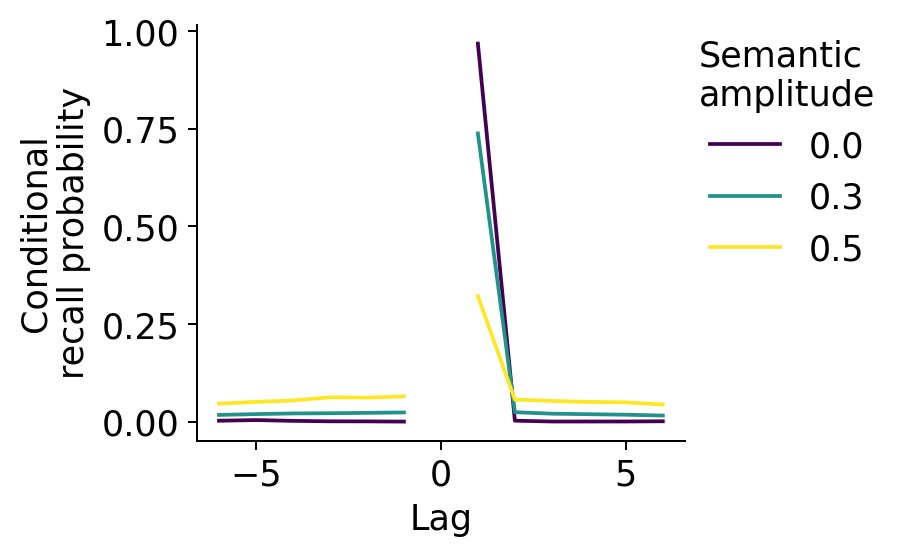

In [ ]:
crp_by_noise_std_hier = df_semantic.groupby("semantic_amp")["crp_curve"]
# print(crp_by_noise_std.head())
mean_crp_by_noise_std_hier = []
for name, group in crp_by_noise_std_hier:
    crp_arrays = np.array(group.tolist())
    mean_crp = np.mean(np.stack(crp_arrays, axis=0), axis=0)
    mean_crp_by_noise_std_hier.append(mean_crp)
mean_crp_by_noise_std_hier = np.array(mean_crp_by_noise_std_hier)

print(mean_crp_by_noise_std_hier.shape)

# colors = ["tab:blue", "tab:red", "tab:green", "tab:purple", "tab:orange", "tab:brown"]
# colors = ["#FF8811", "#F4D06F", "#5AA9E6", "#7FC8F8", "tab:blue", "tab:red"]
colors = plt.cm.viridis(np.linspace(0, 1, len(semantic_amp)))
plot_crp_by_group(mean_crp_by_noise_std_hier, semantic_amp, 
                "Semantic\namplitude", colors)


In [ ]:
semantic_contiguity = df_semantic.groupby("semantic_amp")["semantic_contiguity"]
semantic_contiguity_baseline = df_semantic.groupby("semantic_amp")["semantic_contiguity_baseline"]

sem_cont_norms = []
for name, group in semantic_contiguity:
    sem_cont_norm = np.array(group.tolist())
    sem_cont_norms.append(sem_cont_norm / np.sum(sem_cont_norm, axis=1, keepdims=True))


sem_cont_norms_baseline = []
for name, group in semantic_contiguity_baseline:
    sem_cont_norm_baseline = np.array(group.tolist())
    sem_cont_norms_baseline.append(sem_cont_norm_baseline / np.sum(sem_cont_norm_baseline, axis=1, keepdims=True))
    # print(sem_cont_norm_baseline.shape)

# print(sem_cont_norms_baseline)

semantic_contiguity_processed = []
semantic_contiguity_processed_std = []
for i in range(len(sem_cont_norms)):
    sem_count_processed = sem_cont_norms[i] / (sem_cont_norms_baseline[i] + 1e-6)
    data_processed = []
    for j in range(len(sem_count_processed)):
        data_processed.append(sem_count_processed[j])
    data_processed = np.array(data_processed)
    print(data_processed.shape)
    semantic_contiguity_processed.append(np.mean(data_processed, axis=0))
    print(np.std(sem_cont_norms[i], axis=0), np.mean(sem_cont_norms_baseline[i], axis=0))
    semantic_contiguity_processed_std.append(np.std(sem_cont_norms[i], axis=0))
    # semantic_contiguity_processed_std.append(np.std(data_processed, axis=0))

# print(sem_cont_norms) 
# print(sem_cont_norms_baseline)
print(semantic_contiguity_processed)
print(semantic_contiguity_processed_std)

(19, 3)
[0.00279205 0.00829437 0.00631031] [0.00910843 0.7475804  0.24331118]
(19, 3)
[0.02685756 0.02117068 0.00595357] [0.76088608 0.19152685 0.04758708]
(18, 3)
[0.02969441 0.02348293 0.00694492] [0.7621277  0.19052516 0.04734714]
[array([1.0304842 , 0.99923799, 1.00066092]), array([0.98479179, 1.04651558, 1.05572826]), array([0.95918387, 1.12671462, 1.16754082])]
[array([0.00279205, 0.00829437, 0.00631031]), array([0.02685756, 0.02117068, 0.00595357]), array([0.02969441, 0.02348293, 0.00694492])]


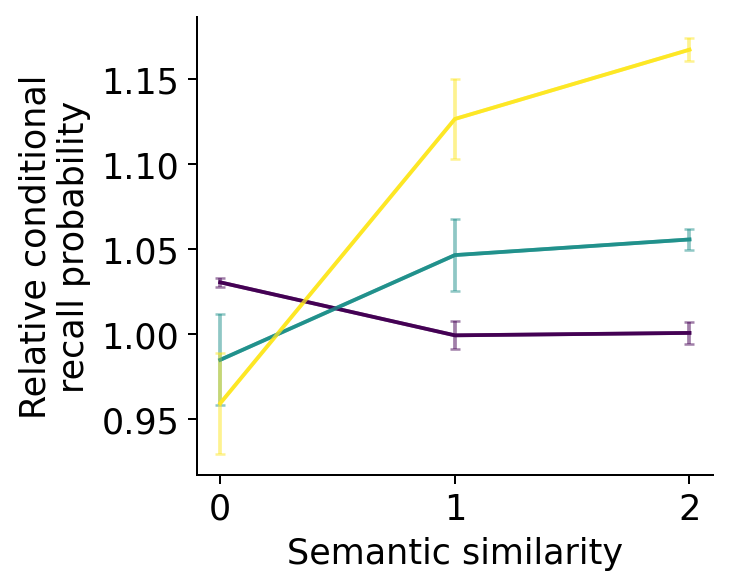

In [ ]:
plt.figure(figsize=(3.7, 3.3), dpi=180)
settings_name = semantic_amp
for i in range(len(semantic_contiguity_processed)):
    plt.plot(semantic_contiguity_processed[i], label=settings_name[i], color=colors[i])
    plt.errorbar(np.arange(len(semantic_contiguity_processed[i])), semantic_contiguity_processed[i], yerr=semantic_contiguity_processed_std[i], color=colors[i], capsize=2, alpha=0.5)

plt.xticks(np.arange(0, 3), [0, 1, 2])

plt.xlabel("Semantic similarity")
plt.ylabel("Relative conditional\nrecall probability")
# plt.legend(title="Semantic\namplitude", 
#         bbox_to_anchor=(1.0, 1.0), 
#         loc="upper left", 
#         borderaxespad=0, 
#         frameon=False,
#         fontsize=12)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()



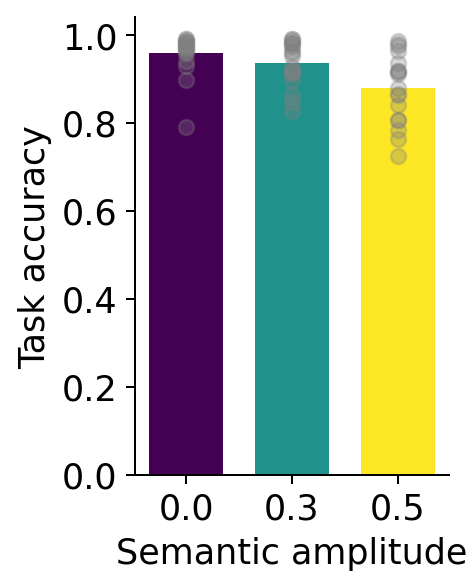

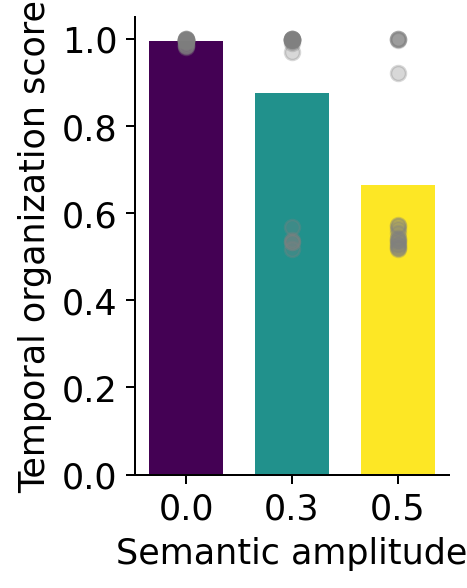

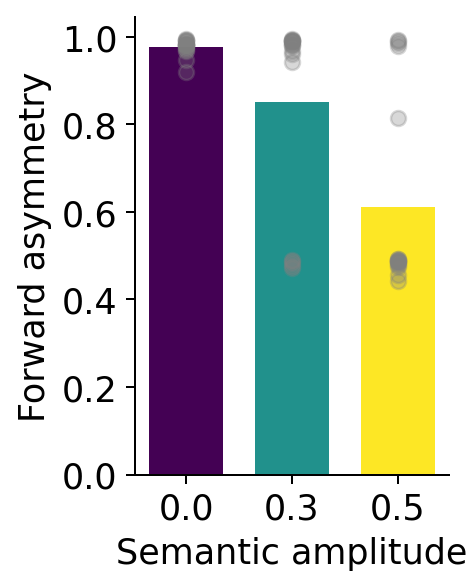

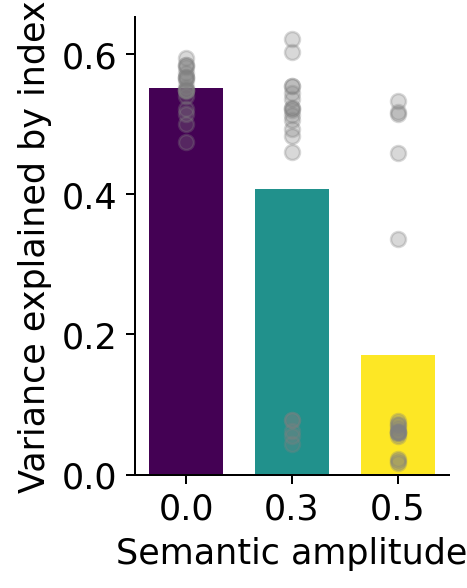

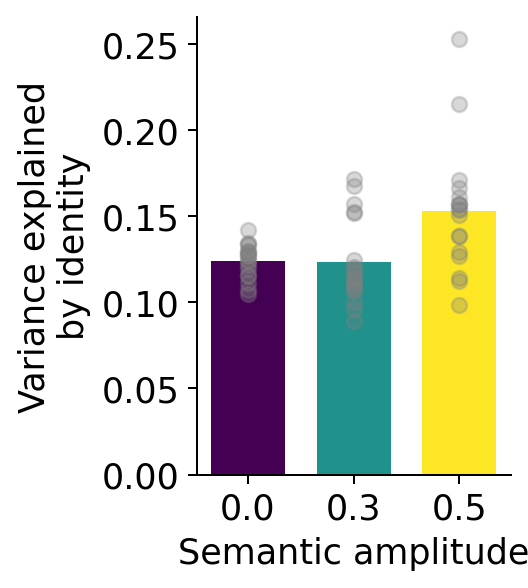

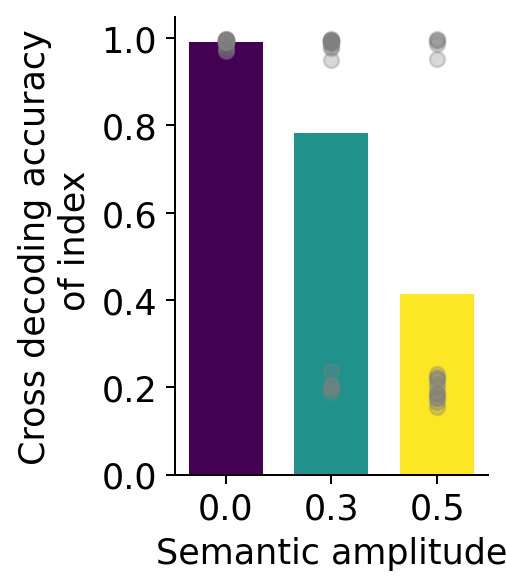

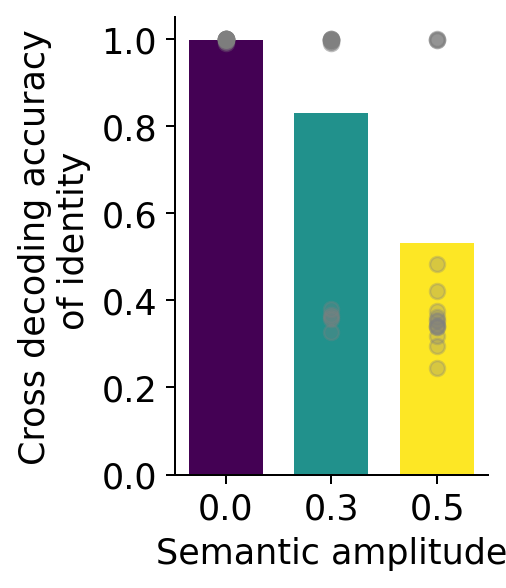

In [ ]:
# bar plot of each metric for each noise std

accuracy_mean_by_noise_std = df_semantic.groupby("semantic_amp")["accuracy"].mean()
accuracy_std_by_noise_std = df_semantic.groupby("semantic_amp")["accuracy"].std()

temporal_factor_mean_by_noise_std = df_semantic.groupby("semantic_amp")["temporal_factor"].mean()
temporal_factor_std_by_noise_std = df_semantic.groupby("semantic_amp")["temporal_factor"].std()

forward_asymmetry_mean_by_noise_std = df_semantic.groupby("semantic_amp")["forward_asymmetry"].mean()
forward_asymmetry_std_by_noise_std = df_semantic.groupby("semantic_amp")["forward_asymmetry"].std()

variance_explained_index_mean_by_noise_std = df_semantic.groupby("semantic_amp")["explained_variance_index"].mean()
variance_explained_identity_mean_by_noise_std = df_semantic.groupby("semantic_amp")["explained_variance_identity"].mean()

cross_decoding_accuracy_index_mean_by_noise_std = df_semantic.groupby("semantic_amp")["cross_decoding_accuracy_index"].mean()
cross_decoding_accuracy_identity_mean_by_noise_std = df_semantic.groupby("semantic_amp")["cross_decoding_accuracy_identity"].mean()


# viridis = plt.get_cmap('viridis', lut=len(noise_stds))
# colors = [viridis(i) for i in range(len(noise_stds))]
df_semantic["mark"] = df_semantic["semantic_amp"].map(lambda x: semantic_amp.index(x)+1)

def plot_mean_scatter_bar(mean, df, df_label, y_label, x_ticks=None):
    plt.figure(figsize=(2.25, 3.3), dpi=180)
    plt.bar(np.arange(1, len(mean)+1), mean, width=0.7, color=colors)
    plt.scatter(df["mark"], df[df_label], color="gray", alpha=0.3)
    plt.xlabel("Semantic amplitude")
    plt.xticks(np.arange(1, len(mean)+1), semantic_amp)
    # if x_ticks is not None:
    #     plt.xticks(np.arange(0, len(mean)), x_ticks, rotation=45, fontsize=12)
    plt.ylabel(y_label)
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.show()

xticks = ["Amplitude 0.2, Discount 1", "Amplitude 0.5, Discount 1", "Amplitude 0.2, Discount 0", "Amplitude 0.5, Discount 0"]
plot_mean_scatter_bar(accuracy_mean_by_noise_std, df_semantic, "accuracy", "Task accuracy", xticks)
plot_mean_scatter_bar(temporal_factor_mean_by_noise_std, df_semantic, "temporal_factor", "Temporal organization score", xticks)
plot_mean_scatter_bar(forward_asymmetry_mean_by_noise_std, df_semantic, "forward_asymmetry", "Forward asymmetry", xticks)
plot_mean_scatter_bar(variance_explained_index_mean_by_noise_std, df_semantic, "explained_variance_index", "Variance explained by index", xticks)
plot_mean_scatter_bar(variance_explained_identity_mean_by_noise_std, df_semantic, "explained_variance_identity", "Variance explained\nby identity", xticks)
plot_mean_scatter_bar(cross_decoding_accuracy_index_mean_by_noise_std, df_semantic, "cross_decoding_accuracy_index", "Cross decoding accuracy\n of index", xticks)
plot_mean_scatter_bar(cross_decoding_accuracy_identity_mean_by_noise_std, df_semantic, "cross_decoding_accuracy_identity", "Cross decoding accuracy\n of identity", xticks)



### clustering

In [ ]:
df = pd.read_pickle("../data/df_models.pkl")

In [ ]:
df_for_clustering = df[(df["accuracy"] >= 0.6) & (df["temporal_factor"] >= 0.5) & (df["item_decoding_accuracy"] >= 0.6) & (df["wm_noise"] >= 0.0)].copy()
print(len(df_for_clustering))

755


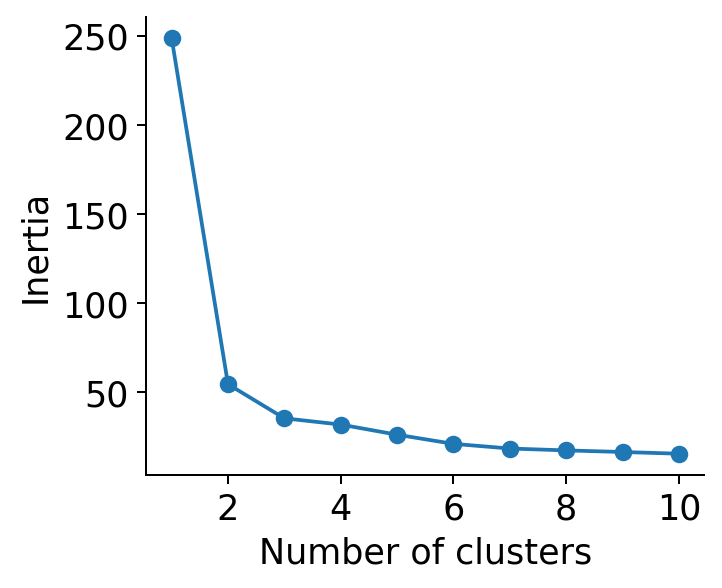

In [ ]:
""" test best number of clusters """

from sklearn.preprocessing import StandardScaler, MinMaxScaler, QuantileTransformer, PowerTransformer, normalize
from sklearn.cluster import KMeans  
from sklearn.metrics import silhouette_score

features = ["forward_asymmetry", "temporal_factor",
            "index_decoding_accuracy", "item_decoding_accuracy", "last_item_decoding_accuracy",
            "explained_variance_index", "explained_variance_identity", 
            "cross_decoding_accuracy_index", "cross_decoding_accuracy_identity",
            # "item_invariance_cross_phase_accuracy_last", "time_invariance_cross_phase_accuracy_last"
            ]

X = df_for_clustering[features]

# scaler = StandardScaler()
# scaler = MinMaxScaler()
# X_normalized = scaler.fit_transform(X)
# X_normalized = normalize(X, norm='l1')
X_normalized = X

# Determine the optimal number of clusters with elbow method
inertia = []
silhoutte_score = []
for n_clusters in range(1, 11):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(X_normalized)
    labels = kmeans.labels_
    inertia.append(kmeans.inertia_)
    if n_clusters > 1:
        silhoutte_score.append(silhouette_score(X_normalized, labels))

plt.figure(figsize=(4, 3.3), dpi=180)
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# plt.title('Inertia for Optimal Number of Clusters')
plt.show()

# plt.figure(figsize=(4, 3.3), dpi=180)
# plt.plot(range(2, 11), silhoutte_score, marker='o')
# plt.xlabel('Number of clusters')
# plt.ylabel('Silhouette score')
# ax = plt.gca()
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# plt.show()

In [ ]:
""" cluster based on the chosen number of clusters """
# make the optimal number of clusters\

# Fit the KMeans model with the optimal number of clusters
optimal_clusters = 3
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(X_normalized)
df_for_clustering["cluster"] = cluster_labels

# Add silhouette score to evaluate clustering quality
silhouette_avg = silhouette_score(X_normalized, cluster_labels)
print(f'Silhouette Score for {optimal_clusters} clusters: {silhouette_avg}')



Silhouette Score for 3 clusters: 0.5650606822437969


In [ ]:
# print number of items for each cluster
for i in range(optimal_clusters):
    print(f'Cluster {i+1}: {len(df_for_clustering[df_for_clustering["cluster"] == i])} items')
# print 5 info for each cluster
for i in range(optimal_clusters):
    print(f'Cluster {i+1}:')
    print(df_for_clustering[df_for_clustering['cluster'] == i][["temporal_discount_factor", "noise_level", "model_num"]].tail())

Cluster 1: 390 items
Cluster 2: 225 items
Cluster 3: 140 items
Cluster 1:
      temporal_discount_factor  noise_level  model_num
2133                       1.0          0.8         13
2134                       1.0          0.8         14
2135                       1.0          0.8         15
2136                       1.0          0.8         16
2139                       1.0          0.8         19
Cluster 2:
      temporal_discount_factor  noise_level  model_num
2154                       1.0          1.0         14
2156                       1.0          1.0         16
2157                       1.0          1.0         17
2158                       1.0          1.0         18
2159                       1.0          1.0         19
Cluster 3:
      temporal_discount_factor  noise_level  model_num
2124                       1.0          0.8          4
2127                       1.0          0.8          7
2137                       1.0          0.8         17
2145                    

In [ ]:
features = ["forward_asymmetry", "temporal_factor",
            "index_decoding_accuracy", "item_decoding_accuracy", "last_item_decoding_accuracy",
            "explained_variance_index", "explained_variance_identity", 
            "cross_decoding_accuracy_index", "cross_decoding_accuracy_identity",
            # "item_invariance_cross_phase_accuracy_last", "time_invariance_cross_phase_accuracy_last"
            ]



X = df_ctx[features]
# X_normalized = scaler.transform(X)
X_normalized = X

cluster_labels_ctx = kmeans.predict(X_normalized)
df_ctx.loc[:, "cluster"] = cluster_labels_ctx

print(cluster_labels_ctx)

# Swap cluster labels 0 and 1 in df_ctx['cluster']
df_ctx['cluster'] = df_ctx['cluster'].map({0: 1, 1: 0}).fillna(df_ctx['cluster']).astype(int)




[0 0 0 1 0 0 0 1 0 2 0 0 0 2 0 0 0 0 0 0 1 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 1 1
 2 2 2 2 1 1 2 2 1 2 2 2 2 2 2 2 2 2 2 2]


In [ ]:
# distribution of strategies in each factor

def plot_bar_by_strategy(df, x, x_label, x_ticks=None):
    plt.figure(figsize=(2.2, 3.3), dpi=180)
    
    cluster_distribution = df.groupby(["cluster", x]).size().unstack(fill_value=0)
    sum_distribution = cluster_distribution.sum(axis=0)
    cluster_distribution = cluster_distribution.div(sum_distribution, axis=1)
    cumsum_distribution = cluster_distribution.cumsum(axis=0)

    for i, row in cumsum_distribution.iterrows():
        plt.bar(np.arange(0, len(row.index)), row.values, color=colormap[i], label=f"Cluster {i}", width=0.7, zorder=-i)
    plt.xlabel(x_label)
    plt.ylabel("Distribution of strategies")

    unique_x = df[x].unique()
    if x_ticks is not None:
        plt.xticks(np.arange(0, len(unique_x)), x_ticks)
    else:
        plt.xticks(np.arange(0, len(unique_x)), list(unique_x))
    
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.show()


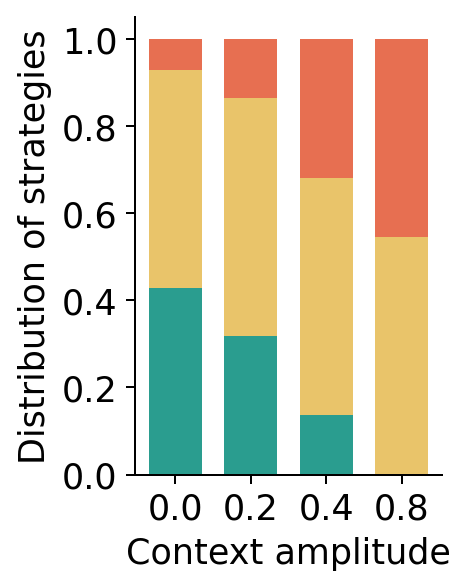

In [ ]:

colormap = np.array(["#2A9D8F", "#E9C46A", "#E76F51", "#F4A261", "#264653"]) 

# patches = [mpatches.Patch(color="#2A9D8F", label="Strategy 1: Memory palace"),
#            mpatches.Patch(color="#E76F51", label="Strategy 2: TCM-like forward"),
#            mpatches.Patch(color="#E9C46A", label="Strategy 3: Backward recall"),
#            mpatches.Patch(color="#264653", label="Reservoir RNN")]

plot_bar_by_strategy(df_ctx, "noise_std", "Context amplitude")